In [1]:
import itertools

from pathlib import Path
from IPython.display import display_markdown

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
import seaborn as sns
from scipy.stats import mannwhitneyu

In [2]:
results_paths = [
    Path('../../results/quantum_entropy'),
    Path('../../results/kaoetal'),
    Path('../../results/local_global_surprise')
]
corpora = [
    'semeval',
    'humicroedit',
    'expunations',
    'cup',
    'joker_clef_en',
    'joker_clef_es',
    'HAHA@IberLEF2021',
    'HUHU@IberLEF2023',
    'joker_clef_fr',
    'joker_clef_pt',
    'clemencio',
    'puntuguese',
    'chumor'
]
metrics = [
    'QE-U + GloVe',
    'QE-I + GloVe',
    'QE-U + HF',
    'QE-I + HF',
    'local global surprise',
    'ambiguity',
    'distinctiveness'
]

In [3]:
dfs = []
for results_path in results_paths:
    for corpus in corpora:
        readpath = results_path / (corpus + '.jsonl')
        if readpath.exists():
            df = (pl.read_ndjson(readpath)
                    .with_columns(pl.lit(corpus).alias('corpus'))
                    .drop(['funniness', 'location', 'interpretation', 'char_count'], strict=False))
            if 'label' not in df.columns:
                df = df.with_columns(pl.lit(1).alias('label'))
            df = df.filter(pl.col('label') == 1)
            dfs.append(df)

combined_df = pl.concat(dfs, how='diagonal_relaxed')
df = (combined_df.group_by(['index', 'text', 'corpus'])
                 .agg([pl.col(m).drop_nulls().first() for m in metrics if m in combined_df.columns]))

datasets_enum = pl.Enum(corpora)
df = (df.with_columns(pl.lit('Humor').alias('label'))
     .sort(pl.col('corpus').cast(datasets_enum)))
df

index,text,corpus,QE-U + GloVe,QE-I + GloVe,QE-U + HF,QE-I + HF,local global surprise,ambiguity,distinctiveness,label
str,str,str,f64,f64,f64,f64,f64,f64,f64,str
"""semeval.hom_1986""","""I tinted my hair today. It was…","""semeval""",4.952364,-4.808701,0.757951,-0.513212,null,null,null,"""Humor"""
"""semeval.hom_55""","""I made a batch of fish eye sou…","""semeval""",5.140185,-4.998647,0.528868,-0.312207,null,null,null,"""Humor"""
"""semeval.hom_1587""","""OLD LANDSCAPERS never die, the…","""semeval""",5.047668,-4.909831,0.54757,-0.33061,null,null,null,"""Humor"""
"""semeval.hom_233""","""There was a massive outcry aga…","""semeval""",5.00856,-4.858454,0.655812,-0.40025,null,null,null,"""Humor"""
"""semeval.hom_206""","""She was only a Gardener's daug…","""semeval""",4.993336,-4.849899,0.548859,-0.324151,null,null,null,"""Humor"""
…,…,…,…,…,…,…,…,…,…,…
"""chumor.1966""","""标题：“你自己掰了一千吨玉米?！”“哈哈我瞎掰的”""","""chumor""",5.530845,-5.487385,0.628846,-0.395385,null,null,null,"""Humor"""
"""chumor.2531""","""标题：所谓久别胜新婚, 两个十年未见的仇人被法官判定当庭结婚""","""chumor""",5.499259,-5.458013,0.677365,-0.410527,null,null,null,"""Humor"""
"""chumor.85""","""标题：突然冲出一个人骂我是猪！我当时就气得哼唧哼唧说不出话.""","""chumor""",5.516529,-5.469869,0.613894,-0.35775,null,null,null,"""Humor"""


### Remove error values

- -1 for Surprise Ratio
- 0 for Ambiguity and Distinctiveness

In [13]:
df = (df.with_columns(pl.col('local global surprise').replace(-1, None))
        .with_columns(pl.col('ambiguity').replace(0, None))
        .with_columns(pl.col('distinctiveness').replace(0, None)))
df['ambiguity'].describe()

statistic,value
str,f64
"""count""",3609.0
"""null_count""",11320.0
"""mean""",0.362557
"""std""",0.334225
"""min""",1.1618e-25
"""25%""",0.00006
"""50%""",0.521153
"""75%""",0.693147
"""max""",0.693147


### Quantile analysis

In [5]:
melted_df = (df.unpivot(on=metrics,
                       index=['index', 'label', 'corpus'],
                       variable_name='metric')
               .drop_nulls())
melted_df

index,label,corpus,metric,value
str,str,str,str,f64
"""semeval.hom_1986""","""Humor""","""semeval""","""QE-U + GloVe""",4.952364
"""semeval.hom_55""","""Humor""","""semeval""","""QE-U + GloVe""",5.140185
"""semeval.hom_1587""","""Humor""","""semeval""","""QE-U + GloVe""",5.047668
"""semeval.hom_233""","""Humor""","""semeval""","""QE-U + GloVe""",5.00856
"""semeval.hom_206""","""Humor""","""semeval""","""QE-U + GloVe""",4.993336
…,…,…,…,…
"""puntuguese.5.573.H""","""Humor""","""puntuguese""","""distinctiveness""",6.499971
"""puntuguese.5.2166.H""","""Humor""","""puntuguese""","""distinctiveness""",6.499971
"""puntuguese.5.3318.H""","""Humor""","""puntuguese""","""distinctiveness""",6.500074


In [6]:
quantiles = (melted_df.group_by(['corpus', 'metric'])
                      .agg(pl.col('value').quantile(0.25).alias('Q1'),
                           pl.col('value').quantile(0.5).alias('Q2'),
                           pl.col('value').quantile(0.75).alias('Q3'))
                      .with_columns((pl.col('Q3') - pl.col('Q1')).alias('IQR'))
                      .with_columns((pl.col('Q1') - 1.5 * pl.col('IQR')).alias('F1'),
                                    (pl.col('Q3') + 1.5 * pl.col('IQR')).alias('F2')))

with pl.Config(tbl_rows=60):
    display(quantiles.sort(pl.col('corpus').cast(datasets_enum)))

corpus,metric,Q1,Q2,Q3,IQR,F1,F2
str,str,f64,f64,f64,f64,f64,f64
"""semeval""","""QE-U + HF""",0.534335,0.562347,0.600848,0.066512,0.434567,0.700617
"""semeval""","""QE-U + GloVe""",4.928157,5.00147,5.075655,0.147498,4.70691,5.296901
"""semeval""","""QE-I + HF""",-0.364227,-0.326684,-0.290945,0.073282,-0.47415,-0.181021
"""semeval""","""QE-I + GloVe""",-4.94463,-4.868345,-4.78702,0.15761,-5.181045,-4.550605
"""humicroedit""","""QE-I + HF""",-0.396873,-0.366344,-0.335613,0.061259,-0.488762,-0.243724
"""humicroedit""","""QE-U + HF""",0.528869,0.559969,0.595487,0.066619,0.428941,0.695415
"""humicroedit""","""QE-I + GloVe""",-5.183389,-5.077046,-4.94812,0.235269,-5.536293,-4.595217
"""humicroedit""","""QE-U + GloVe""",5.05372,5.173874,5.264197,0.210478,4.738003,5.579914
"""expunations""","""QE-U + HF""",0.533401,0.559111,0.59734,0.063938,0.437494,0.693247


In [7]:
df_with_quantiles = melted_df.join(quantiles, on=['corpus', 'metric'])
is_low_outlier = (pl.col('value') < pl.col('F1'))
is_high_outlier = (pl.col('value') > pl.col('F2'))
df_no_outliers = df_with_quantiles.filter(~(is_low_outlier | is_high_outlier)).select(melted_df.columns)

with pl.Config(tbl_rows=13):
    display(df_no_outliers.group_by('corpus').len())

corpus,len
str,u64
"""expunations""",1224
"""HAHA@IberLEF2021""",11291
"""humicroedit""",12311
"""joker_clef_fr""",3856
"""cup""",4563
"""joker_clef_en""",5191
"""HUHU@IberLEF2023""",986
"""chumor""",532
"""semeval""",2635


## Plots

### Joint plot

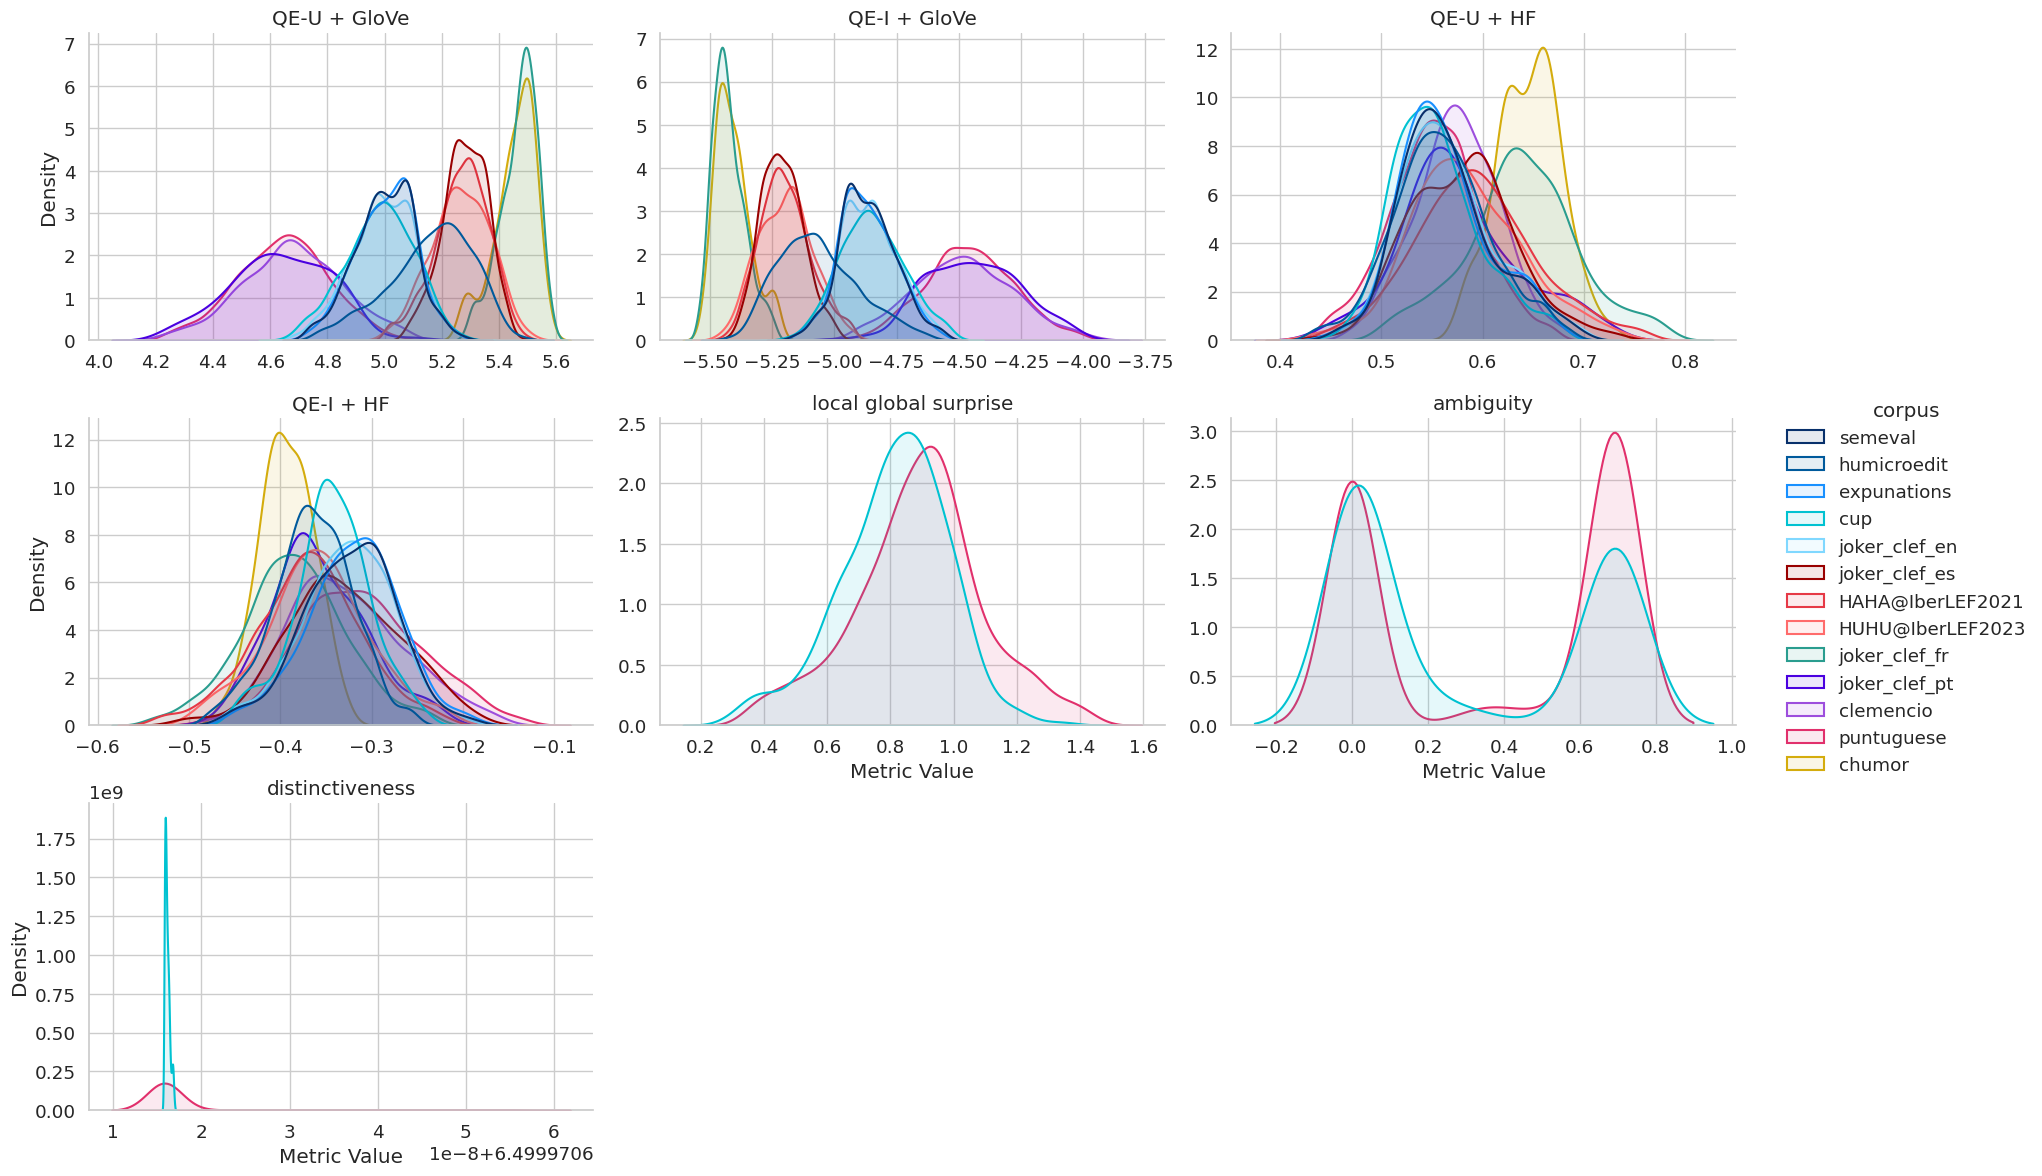

In [8]:
sns.set_theme(style="whitegrid", font_scale=1.2)

corpus_palette = {
    # English (Blue to Cyan spectrum)
    'semeval': '#08306B',         # Very Dark Blue
    'humicroedit': '#005A9C',     # Medium Blue
    'expunations': '#1890FF',     # Vibrant Blue
    'cup': '#00C2D1',             # Teal/Cyan
    'joker_clef_en': '#80D8FF',   # Light Cyan
    
    # Spanish (Red spectrum)
    'joker_clef_es': '#990000',   # Dark Crimson
    'HAHA@IberLEF2021': '#E63946',# Bright Red
    'HUHU@IberLEF2023': '#FF6B6B',# Soft/Light Red 
    
    # French (Green)
    'joker_clef_fr': '#2A9D8F',   # Persian Green
    
    # Portuguese (Purple to Pink spectrum)
    'joker_clef_pt': '#4A00E0',   # Deep Indigo
    'clemencio': '#9D4EDD',       # Bright Purple
    'puntuguese': '#E1306C',      # Magenta/Deep Pink
    
    # Mandarin Chinese (Golden/Amber)
    'chumor': '#D4AC0D'           # Dark Gold / Amber
}


g = sns.displot(
    df_no_outliers,
    x='value',
    hue='corpus',
    col='metric',
    col_wrap=3,
    kind='kde',
    common_norm=False,
    fill=True,
    height=4,
    aspect=1.5,
    facet_kws={'sharex': False, 'sharey': False},
    palette=corpus_palette,
    alpha=0.1,
    linewidth=1.5,
    hue_order=corpora)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Metric Value", "Density")
plt.show()

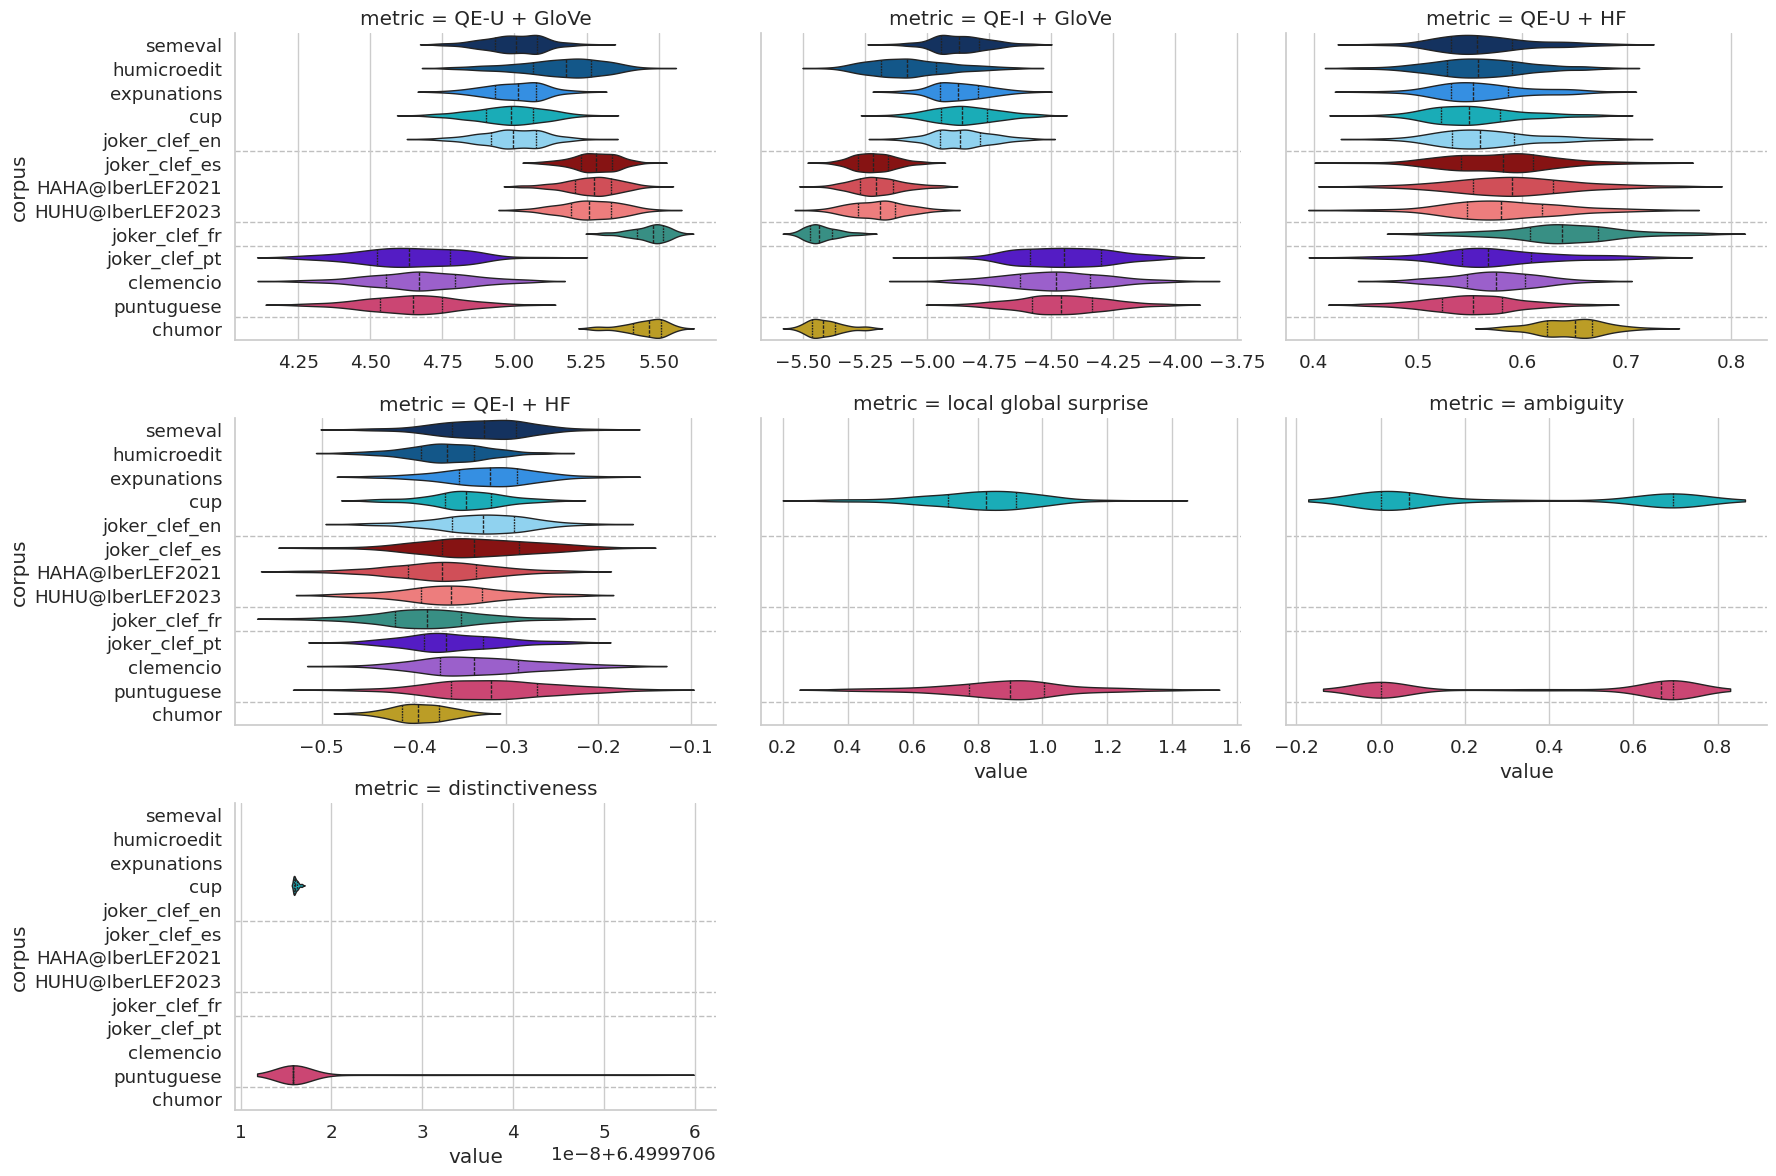

In [9]:
g = sns.catplot(
    data=df_no_outliers,
    x='value',
    y='corpus',
    hue='corpus',
    col='metric',
    col_wrap=3,
    kind='violin',
    sharex=False,
    palette=corpus_palette,
    height=4,
    aspect=1.5,
    linewidth=1,
    inner='quart'
)

separator_positions = [4.5, 7.5, 8.5, 11.5]
for ax in g.axes.flat:
    for y_pos in separator_positions:
        ax.axhline(y_pos, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=0)
plt.show()

## Statistical tests (No outliers)

In [10]:
results = []
for metric in metrics:
    df_metric = df_no_outliers.filter(pl.col('metric') == metric)
    for corpus_a, corpus_b in itertools.combinations(corpora, 2):
        data_a = df_metric.filter(pl.col('corpus') == corpus_a)['value'].drop_nulls()
        data_b = df_metric.filter(pl.col('corpus') == corpus_b)['value'].drop_nulls()

        if data_a.len() > 0 and data_b.len() > 0:
            statistic, pvalue = mannwhitneyu(data_a, data_b, alternative='two-sided')
            results.append({
                'metric': metric,
                'corpus_a': corpus_a,
                'corpus_b': corpus_b,
                'u_statistic': statistic,
                'p_value': pvalue,
                'significantly different': pvalue < 0.05,
                'stable': pvalue >= 0.05
            })

results_df = pl.DataFrame(results).sort(['metric', 'p_value'])
with pl.Config(tbl_rows=11):
    display(
        results_df
        .group_by(['metric'])
        .agg([
            pl.col('stable').sum().alias('stable pairs'),
            pl.col('stable').len().alias('total pairs')
        ])
        .with_columns(
            (pl.col('stable pairs') / pl.col('total pairs') * 100)
            .round(2)
            .alias('stability percentage')
        )
        .sort('stability percentage', descending=True)
    )


metric,stable pairs,total pairs,stability percentage
str,i64,u64,f64
"""ambiguity""",1,1,100.0
"""QE-U + HF""",13,78,16.67
"""QE-I + HF""",11,78,14.1
"""QE-U + GloVe""",7,78,8.97
"""QE-I + GloVe""",6,78,7.69
"""distinctiveness""",0,1,0.0
"""local global surprise""",0,1,0.0


In [11]:
results_df.filter(pl.col('metric').is_in(['ambiguity', 'distinctiveness', 'local global surprise']))

metric,corpus_a,corpus_b,u_statistic,p_value,significantly different,stable
str,str,str,f64,f64,i64,i64
"""ambiguity""","""cup""","""puntuguese""",1079729.5,0.641131,0,1
"""distinctiveness""","""cup""","""puntuguese""",343561.0,4.2184e-95,1,0
"""local global surprise""","""cup""","""puntuguese""",151010.0,1.2817e-10,1,0
